## Store Item Demand Forecasting Challenge (kaggle)



### 1. Problem Identification and Background

In financial management, inventory turnover is a critical factor that can lead to bankruptcy if not properly measured,due to storage high costs, waste and opportunity costs resulting from poor inventory management. The cost of inventory is calculated as follows: Inventory = Cost of capital + Cost of inventory risk + Handling and maintenance costs

**The Business Case: Lowe’s Mexico**

Lowe’s Mexico fell victim to poor inventory management combined with slow growth. Failure to correctly identify which items should be rotated and which should not, coupled with logistical challenges in keeping shelves stocked, caused the operation to become unprofitable.

**Why is inventory management important?**

  If you have a small warehouse (low storage cost): 
  - You have to restock product more often (transportation and shipping costs).
  - Risking running out of stock (low sales).
  - You can't offer discounts on products that are not selling (opportunity cost).

By using machine learning, product demand can be predicted to achieve optimal inventory turnover and replenishment based on seasonal trends and previous annual sales.

## Data Extraction and Preprocessing

Data Description:
- The data consists of daily sales data for 10 different stores and 50 different items, of the kaggle competition "Store Item Demand Forecasting Challenge". The data spans from January 1, 2013, to December 31, 2017. The dataset includes the following columns:
  - date: The date of the sales record.
  - store: The store number (1 to 10).
  - item: The item number (1 to 50).
  - sales: The number of items sold on that date at that store.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns

from pmdarima import auto_arima
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from prophet import Prophet

import itertools



import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
folder = "proyects/"

Importing plotly failed. Interactive plots will not work.


In [5]:
df_train = pd.read_csv(folder + "Demand_Forecasting_train.csv", parse_dates=["date"])
df_val = pd.read_csv(folder + "Demand_Forecasting_test.csv", parse_dates=["date"])
df_train['date'] = pd.to_datetime(df_train['date'])
df_val['date'] = pd.to_datetime(df_val['date'])
df_train = df_train.set_index('date')
df_val = df_val.set_index('date')
print(df_val.head())
print(df_train.head())


            id  store  item
date                       
2018-01-01   0      1     1
2018-01-02   1      1     1
2018-01-03   2      1     1
2018-01-04   3      1     1
2018-01-05   4      1     1
            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10


In [6]:
#let's drop the id column from the validation dataset
df_val = df_val.drop(columns=['id'])

# checking empty, null and duplicated values
print("Empty values in train:", df_train.isnull().sum())
print("Empty values in validation:", df_val.isnull().sum()) 
print("Duplicated values in train:", df_train.duplicated().sum())
print("Duplicated values in validation:", df_val.duplicated().sum())
print("Data types in train:\n", df_train.dtypes)
print("Data types in validation:\n", df_val.dtypes)

Empty values in train: store    0
item     0
sales    0
dtype: int64
Empty values in validation: store    0
item     0
dtype: int64
Duplicated values in train: 872564
Duplicated values in validation: 44500
Data types in train:
 store    int64
item     int64
sales    int64
dtype: object
Data types in validation:
 store    int64
item     int64
dtype: object


In [7]:
df_train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


## Data Visualization and Exploratory Data Analysis

##### Let's see first how many stores we have and how many items we have in the dataset

In [8]:
print(f"Number of unique stores: {df_train['store'].nunique()}")
print(f"Number of unique items: {df_train['item'].nunique()}")

Number of unique stores: 10
Number of unique items: 50


<Figure size 1500x600 with 0 Axes>

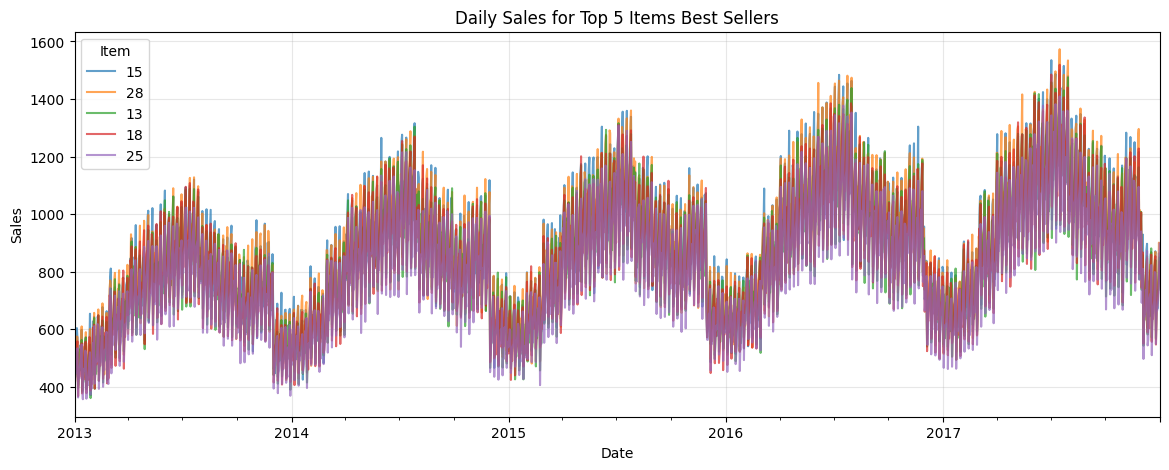

In [9]:
# Plot average daily sales per item (first few items for clarity)
def visualisation_items(df):
    data = df.groupby(['date', 'item'])['sales'].sum().unstack()

    top_items = data.sum().sort_values(ascending=False).head(5).index
    data = data[top_items]
    
    plt.figure(figsize=(15, 6))
    data.iloc[:, :5].plot(title='Daily Sales for Top 5 Items Best Sellers', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend(title='Item')
    plt.grid(True)
    plt.show()
visualisation_items(df_train)
#We can see the item 15 is the best seller

<Figure size 1500x600 with 0 Axes>

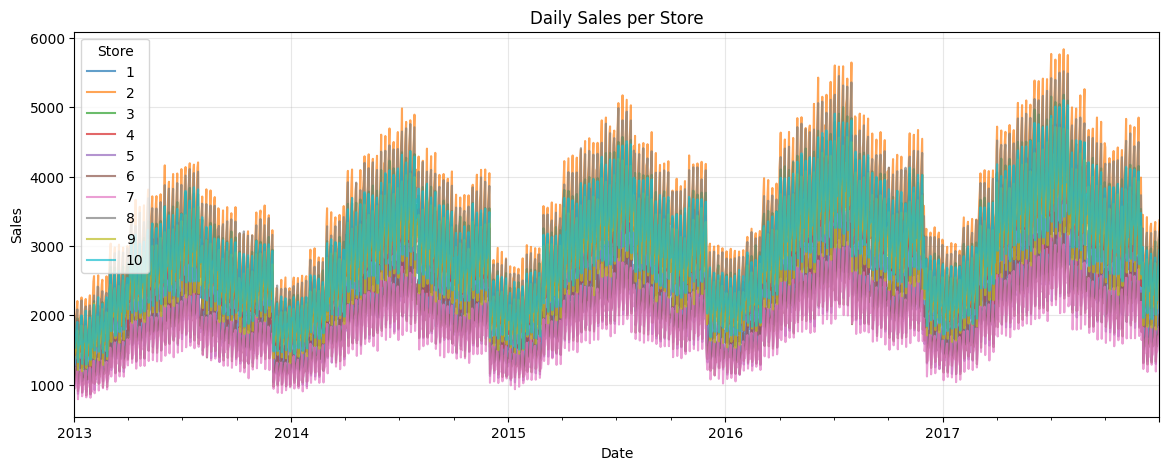

In [10]:
def visualization_stores(df, date_range=None, title='Daily Sales per Store'):
    data = df.copy()
    data.index = pd.to_datetime(data.index)
    data = data.groupby([data.index, 'store'])['sales'].sum().unstack()
    if date_range is not None:
        start, end = pd.to_datetime(date_range[0]), pd.to_datetime(date_range[1])
        data = data.loc[(data.index >= start) & (data.index <= end)]
    plt.figure(figsize=(15, 6))
    data.plot(title=title, alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend(title='Store')
    plt.grid(True)
    plt.show()

#visualization(df_train, date_range=('2014-01-01', '2014-12-31'))
visualization_stores(df_train)


##### Let's take a look closer by year, and by month

<Figure size 1500x600 with 0 Axes>

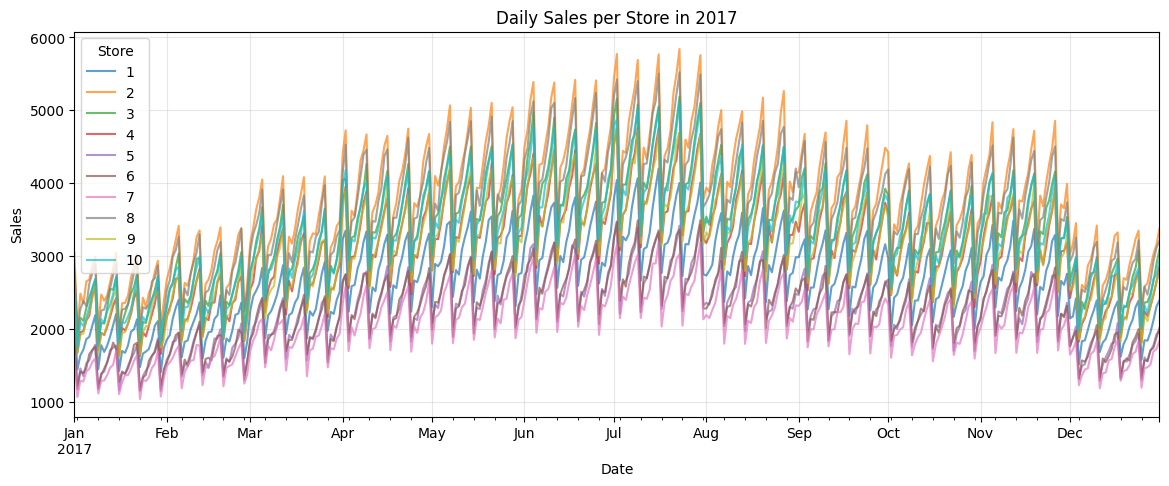

<Figure size 1500x600 with 0 Axes>

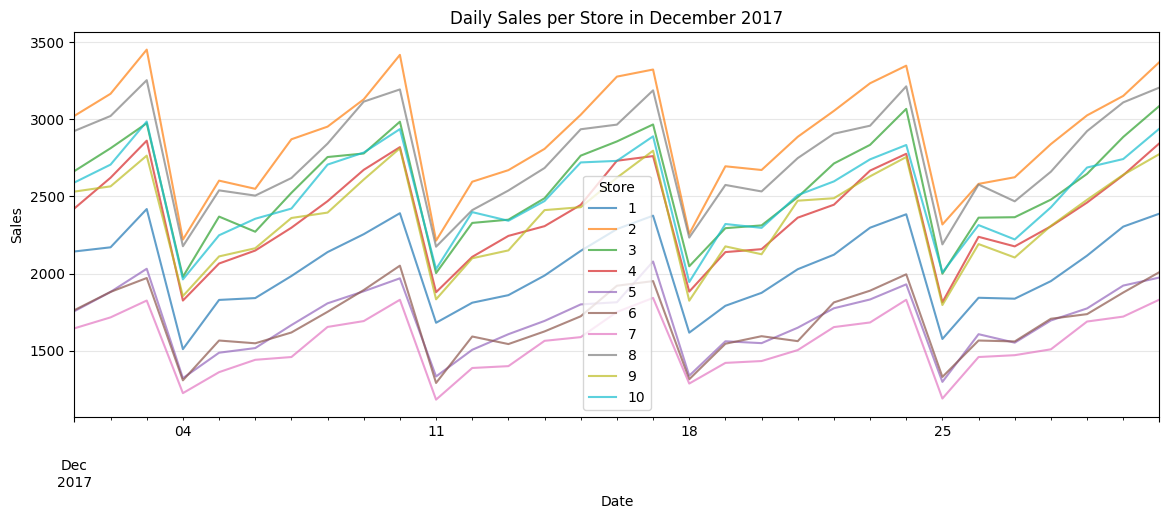

<Figure size 1500x600 with 0 Axes>

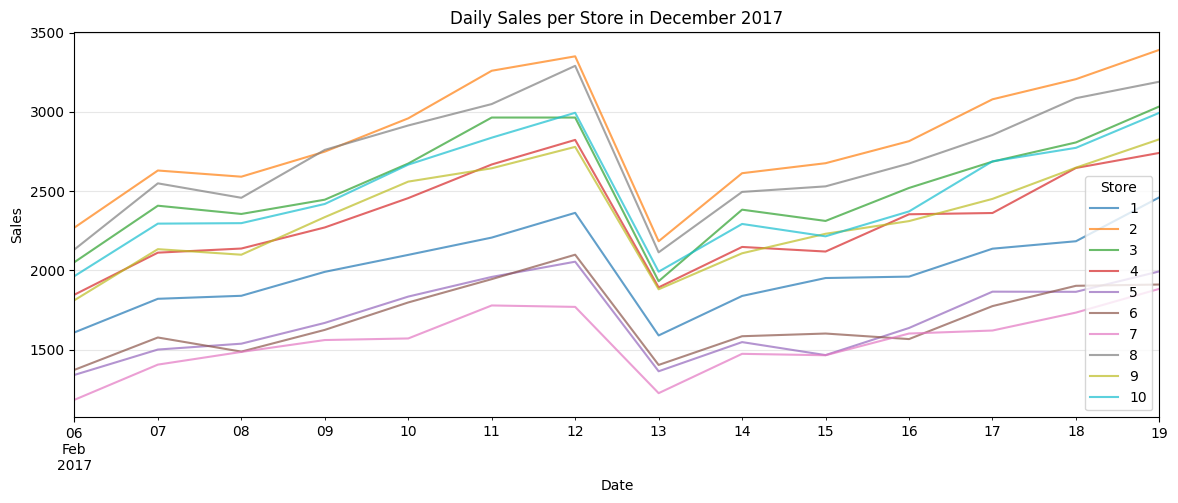

In [11]:
visualization_stores(df_train, date_range=('2017-01-01', '2017-12-31'), title='Daily Sales per Store in 2017')
visualization_stores(df_train, date_range=('2017-12-01', '2017-12-31'), title='Daily Sales per Store in December 2017')
visualization_stores(df_train, date_range=('2017-02-06', '2017-02-19'), title='Daily Sales per Store in December 2017')

We can see a seasonality per year with peaks in Jul-Aug, and a seasonality per week with serials peaks on the weekends, and a drop on the first day of the week, Monday. Let's verfiy in another way the seasonality per week, by plotting the average sales per day of the week.

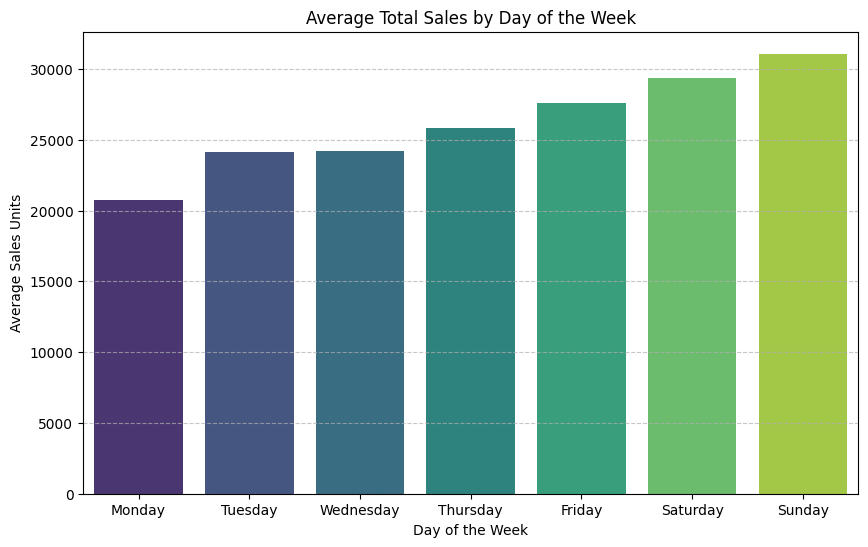

day_of_week
Monday       20714.819231
Tuesday      24112.954023
Wednesday    24184.252874
Thursday     25861.609195
Friday       27578.624521
Saturday     29331.348659
Sunday       31071.666667
Name: total_sales, dtype: float64


In [13]:
data = df_train.copy()
data.index = pd.to_datetime(data.index)
data = data.groupby([data.index, 'store'])['sales'].sum().unstack()
total_daily_sales = data.sum(axis=1).to_frame(name='total_sales')
total_daily_sales['day_of_week'] = total_daily_sales.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern = total_daily_sales.groupby('day_of_week')['total_sales'].mean().reindex(days_order)
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette='viridis')
plt.title('Average Total Sales by Day of the Week')
plt.ylabel('Average Sales Units')
plt.xlabel('Day of the Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(weekly_pattern)

##### We will take the store 2 to do the analysis, because is the store with more sales of all the products, and the best seller product, the product 15.

In [49]:
# the store that have more sells of all the products
store_sales = df_train.groupby('store')['sales'].sum().sort_values(ascending=False)
print("Total sales per store:\n", store_sales)
item_sales = df_train.groupby('item')['sales'].sum().sort_values(ascending=False)
print("Total sales per item:\n", item_sales[:10])
# We can see the store 2 is the store with more sales of all products, and the product 15 is the best seller.

Total sales per store:
 store
2     6120128
8     5856169
3     5435144
10    5360158
9     5025976
4     5012639
1     4315603
5     3631016
6     3627670
7     3320009
Name: sales, dtype: int64
Total sales per item:
 item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
45    1471467
38    1470330
22    1469971
36    1406548
8     1405108
Name: sales, dtype: int64


#### Periodic DataSets

Date range : 2013-01-01 → 2017-12-31
Total days: 1826
Total weeks    : 261
Total months   : 60


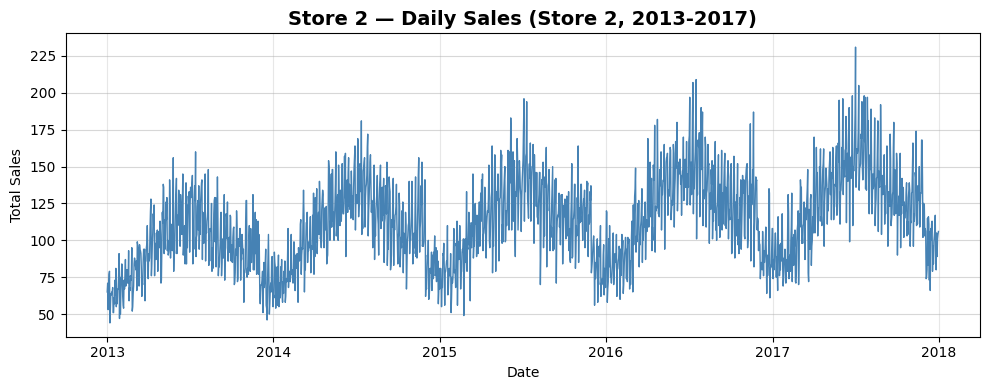

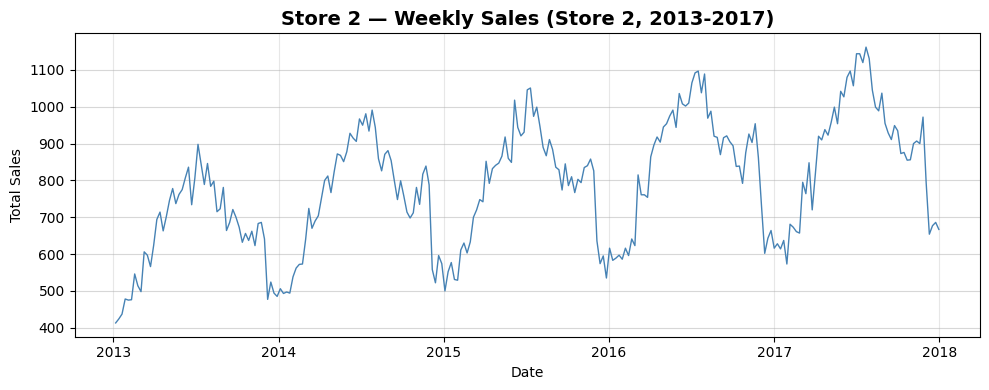

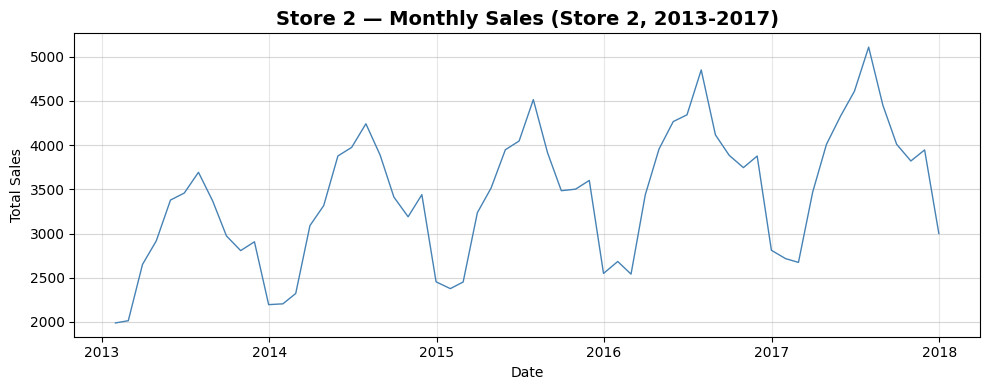

In [50]:
# Keep item 1 only, of the store 2
item15_store_2 = df_train[(df_train['store'] == 2) & (df_train['item'] == 15)].copy()
item15_store_2 = item15_store_2.groupby('date')['sales'].sum()

item15_store_2_weekly = item15_store_2.resample('W').sum()

item15_store_2_monthly = item15_store_2.resample('M').sum()

print(f"Date range : {item15_store_2.index[0].date()} → {item15_store_2.index[-1].date()}")
print(f"Total days: {len(item15_store_2)}")
print(f"Total weeks    : {len(item15_store_2_weekly)}")
print(f"Total months   : {len(item15_store_2_monthly)}")



def plot_sales(data, title='Store 2 — Daily Sales (Store 2, 2013-2017)'):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(data.index, data.values, color='steelblue', linewidth=1.0, markersize=3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales')
    ax.grid(axis='y', alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_sales(item15_store_2)
plot_sales(item15_store_2_weekly, title='Store 2 — Weekly Sales (Store 2, 2013-2017)')
plot_sales(item15_store_2_monthly, title='Store 2 — Monthly Sales (Store 2, 2013-2017)')



In [51]:
train_ts = item15_store_2[item15_store_2.index.year < 2017]
test_ts  = item15_store_2[item15_store_2.index.year == 2017]
train_ts.index = pd.to_datetime(train_ts.index)
test_ts.index = pd.to_datetime(test_ts.index)
train_weekly = train_ts.resample('W').sum()
test_weekly = test_ts.resample('W').sum()
train_monthly = train_ts.resample('M').sum()
test_monthly = test_ts.resample('M').sum()

print(f"Train (2013-2016): {len(train_ts.index.to_period('M').unique())} months  |  Test (2017): {len(test_ts.index.to_period('M').unique())} months")

Train (2013-2016): 48 months  |  Test (2017): 12 months


#### Baseline model: Linear Regression

MAE: 7.61
RMSE: 9.27
MAE: 38.85
RMSE: 51.58
MAE: 156.58
RMSE: 198.51


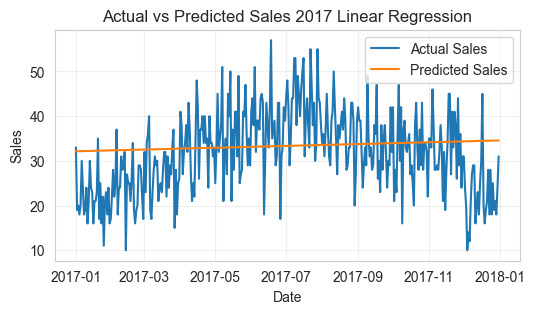

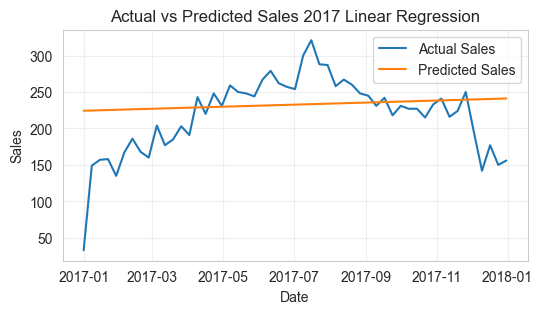

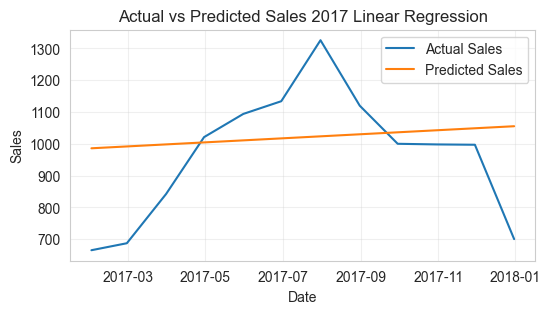

In [ ]:
def baseline_model(train_ts):
    ts = train_ts.reset_index()
    ts['date'] = pd.to_datetime(ts['date'])

    ts['date_num'] = ts['date'].astype('int64') // 10**9 
    X = ts[['date_num']]
    y = ts['sales']

    model = LinearRegression()
    model.fit(X, y)
    return model

def evaluate_model(test_ts, model):
    tt = test_ts.reset_index()
    tt['date'] = pd.to_datetime(tt['date'])
    tt['date_num'] = tt['date'].astype('int64') // 10**9
    X_test = tt[['date_num']]
    y_true = tt['sales']
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")



def visualize_linear_forecast(test_ts, model):
    tt = test_ts.reset_index()
    tt['date'] = pd.to_datetime(tt['date'])
    tt['date_num'] = tt['date'].astype('int64') // 10**9
    X_test = tt[['date_num']]
    tt['pred_sales'] = model.predict(X_test)
    
    plt.figure(figsize=(6, 3))
    plt.plot(tt['date'], tt['sales'], label='Actual Sales')
    plt.plot(tt['date'], tt['pred_sales'], label='Predicted Sales')
    plt.title('Actual vs Predicted Sales 2017 Linear Regression')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

model = baseline_model(train_ts)
model_weekly = baseline_model(train_weekly)
model_monthly = baseline_model(train_monthly)

evaluate_model(test_ts, model)
evaluate_model(test_weekly, model_weekly)
evaluate_model(test_monthly, model_monthly)

visualize_linear_forecast(test_ts, model)
visualize_linear_forecast(test_weekly, model_weekly)
visualize_linear_forecast(test_monthly, model_monthly)


#### Random Forest Regressor 


##### Baseline

In [311]:
ts = train_ts.reset_index()
ts['date'] = pd.to_datetime(ts['date'])
ts['date_num'] = ts['date'].astype('int64') // 10**9 
X = ts[['date_num']]
y = ts['sales']

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

tt = test_ts.reset_index()
tt['date'] = pd.to_datetime(tt['date'])
tt['date_num'] = tt['date'].astype('int64') // 10**9
X_test = tt[['date_num']]
y_true = tt['sales']
y_pred = model.predict(X_test)
    
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 8.76
RMSE: 10.80


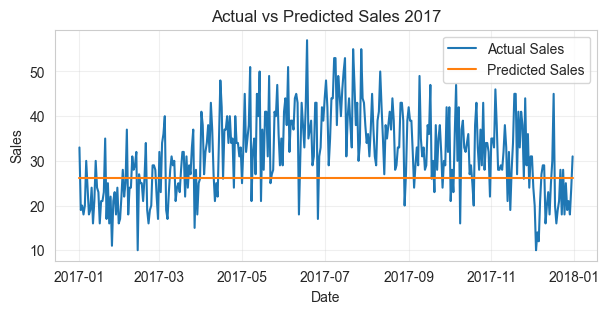

In [313]:
tt['pred_sales'] = model.predict(X_test)
plt.figure(figsize=(7, 3))
plt.plot(tt['date'], tt['sales'], label='Actual Sales')
plt.plot(tt['date'], tt['pred_sales'], label='Predicted Sales')
plt.title('Actual vs Predicted Sales 2017')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

##### Random Forest regressor treats every row as an independent observation. If you feed it a raw date, it won't know that January 2nd follows January 1st. To make this work, you have to transform your time series into a supervised learning problem through **feature engineering**.

In [316]:
def train_random_forest(train_ts):
    data = train_ts.to_frame()
    data['day_of_week'] = data.index.dayofweek
    data['lag_1'] = data['sales'].shift(1)  # Yesterday's sales
    data['lag_2'] = data['sales'].shift(2)  # Two days ago
    data.dropna(inplace=True)
    X = data[['day_of_week', 'lag_1', 'lag_2']]
    y = data['sales']
    model = RandomForestRegressor(n_estimators=100)
    model.fit(X, y)
    return model
model_rf = train_random_forest(train_ts)
model_rf_weekly = train_random_forest(train_weekly)
model_rf_monthly = train_random_forest(train_monthly)

MAE: 5.87
RMSE: 7.31


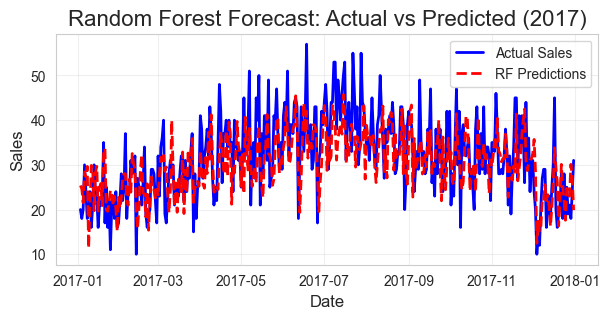

MAE: 18.83
RMSE: 25.92


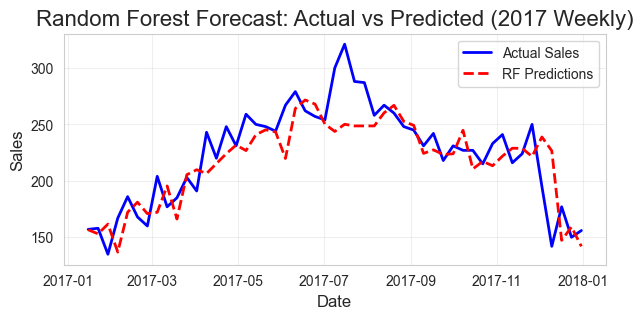

MAE: 129.88
RMSE: 186.82


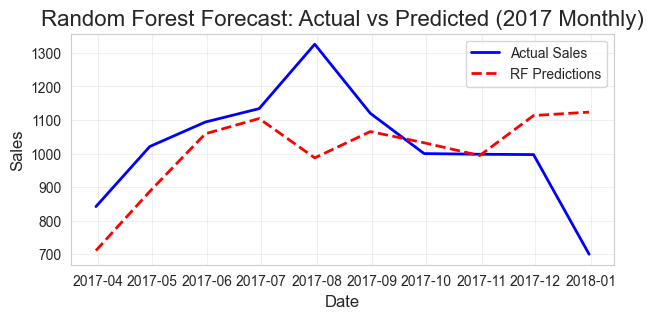

MAE: 4.95
RMSE: 5.98


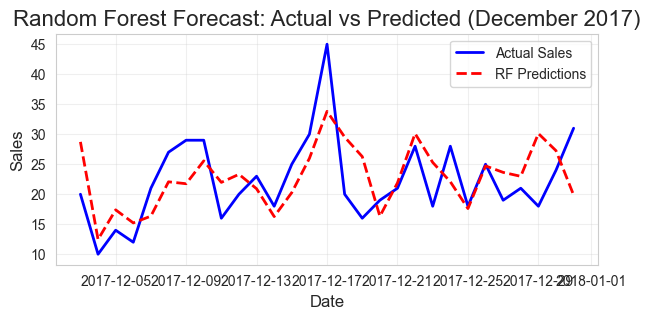

In [318]:
def evaluate_rf(test, model, title='Random Forest Forecast: Actual vs Predicted (2017)'):
    data = test.to_frame()
    data['day_of_week'] = data.index.dayofweek
    data['lag_1'] = data['sales'].shift(1)
    data['lag_2'] = data['sales'].shift(2)
    data.dropna(inplace=True)
    X_test = data[['day_of_week', 'lag_1', 'lag_2']]
    data['pred_sales'] = model.predict(X_test)
    mae = mean_absolute_error(data['sales'], data['pred_sales'])
    rmse = np.sqrt(mean_squared_error(data['sales'], data['pred_sales']))
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    
    plt.figure(figsize=(7, 3))
    plt.plot(data.index, data['sales'], label='Actual Sales', color='blue', linewidth=2)
    plt.plot(data.index, data['pred_sales'], label='RF Predictions', color='red', linestyle='--', linewidth=2)
    plt.title(title, fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

evaluate_rf(test_ts, model_rf)
evaluate_rf(test_weekly, model_rf_weekly, title='Random Forest Forecast: Actual vs Predicted (2017 Weekly)')
evaluate_rf(test_monthly, model_rf_monthly, title='Random Forest Forecast: Actual vs Predicted (2017 Monthly)')

filtered = test_ts.loc['2017-12']
evaluate_rf(filtered, model_rf, title='Random Forest Forecast: Actual vs Predicted (December 2017)')

##### Model Sarimax

In [281]:
# Find the best parameters automatically
stepwise_fit = auto_arima(train_ts, start_p=1, start_q=1,
                          max_p=3, max_q=3, m=7, # m=7 for weekly
                          start_P=0, seasonal=True,
                          d=1, D=1, trace=True,
                          error_action='ignore',  
                          suppress_warnings=True, 
                          stepwise=True)

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=inf, Time=2.40 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=10987.100, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=10097.421, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.96 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=10565.412, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=9951.727, Time=0.51 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=3.36 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=1.39 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=10344.656, Time=0.42 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=9801.498, Time=0.67 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=9942.201, Time=0.37 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=4.76 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=2.31 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=9729.695, Time=0.76 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=9882.834, Time=0.

In [ ]:
def train_sarima(data):
    model = SARIMAX(
        data,
        order=(2, 1, 2),# (p, d, q)
        seasonal_order=(2, 1, 0, 7), # (P, D, Q, s)
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    print(result.summary())
    return result
result = train_sarima(train_ts)
result_weekly = train_sarima(train_weekly)
result_monthly = train_sarima(train_monthly)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1461
Model:             SARIMAX(2, 1, 2)x(2, 1, [], 7)   Log Likelihood               -4695.544
Date:                            Sun, 12 Apr 2026   AIC                           9405.087
Time:                                    15:31:34   BIC                           9441.980
Sample:                                01-01-2013   HQIC                          9418.861
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8093      0.098      8.288      0.000       0.618       1.001
ar.L2          0.0140      0.036   

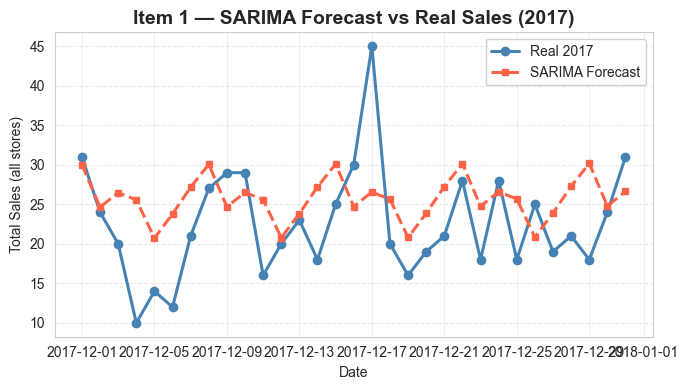

In [ ]:
def visualize_sarima_forecast(model, data):
        forecast = model.get_forecast(steps=len(data))
        pred_mean1 = forecast.predicted_mean
        pred_mean1.index = data.index   # align index
        fig, ax = plt.subplots(figsize=(7, 3))
        start = "2017-12-01"
        end = "2017-12-31"
        data_f = data.loc[start:end]
        pred_mean1_f = pred_mean1.loc[start:end]
        # 2017 real sales
        ax.plot(data_f.index, data_f.values,color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017')

        # SARIMA prediction
        ax.plot(pred_mean1_f.index, pred_mean1_f.values, color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5, label='SARIMA Forecast')

        ax.set_title('Item 1 — SARIMA Forecast vs Real Sales (2017)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Total Sales (all stores)')
        ax.legend(framealpha=0.9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

visualize_sarima_forecast(result,test_ts)
visualize_sarima_forecast(result_weekly,test_weekly)
visualize_sarima_forecast(result_monthly,test_monthly)

#### XGBoost Regressor

Raw dates aren't easily understood by most machine learning models (like Random Forest or XGBoost), so we decompose the date into features that represent time cycles , like **Rolling Windows**, the average or standard deviation of the last 7 or 30 days, or **Calendar Features**, extract the day of the week, month, or whether it's a holiday to help the model learn that sales might spike every Saturday or drop every January, in our case **drop every august, and every monday**.

In [ ]:
def create_features(df):
    """
    Creates time series features from a datetime index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    
    # Lag Features (The manual way)
    # This tells the model what happened 7, 14, and 30 days ago
    df['lag7'] = df['sales'].shift(7)
    df['lag14'] = df['sales'].shift(14)
    df['lag30'] = df['sales'].shift(30)
    
    # Rolling Mean (Smoothing)
    df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
    
    return df


df_xgb = item15_store_2.to_frame(name='sales')
df_xgb_features = create_features(df_xgb).dropna()

train = df_xgb_features[df_xgb_features.index.year < 2017]
test = df_xgb_features[df_xgb_features.index.year == 2017]

def train_xgboost(train, test):
        # Define Features (X) and Target (y)
        FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 
                'lag7', 'lag14', 'lag30', 'rolling_mean_7']
        TARGET = 'sales'

        X_train = train[FEATURES]
        y_train = train[TARGET]

        X_test = test[FEATURES]
        y_test = test[TARGET]

        # Initialize the model
        reg = xgb.XGBRegressor(n_estimators=1000, 
                        early_stopping_rounds=50,
                        learning_rate=0.01,
                        max_depth=5)

        # Fit the model
        reg.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=100)
        
        return reg

model_xgb = train_xgboost(train, test)

[0]	validation_0-rmse:8.14835	validation_1-rmse:10.07532


[100]	validation_0-rmse:5.62140	validation_1-rmse:7.29072
[200]	validation_0-rmse:4.86129	validation_1-rmse:6.55368
[300]	validation_0-rmse:4.48854	validation_1-rmse:6.33931
[400]	validation_0-rmse:4.23651	validation_1-rmse:6.26039
[450]	validation_0-rmse:4.14065	validation_1-rmse:6.27156


MAE: 4.97
RMSE: 6.26


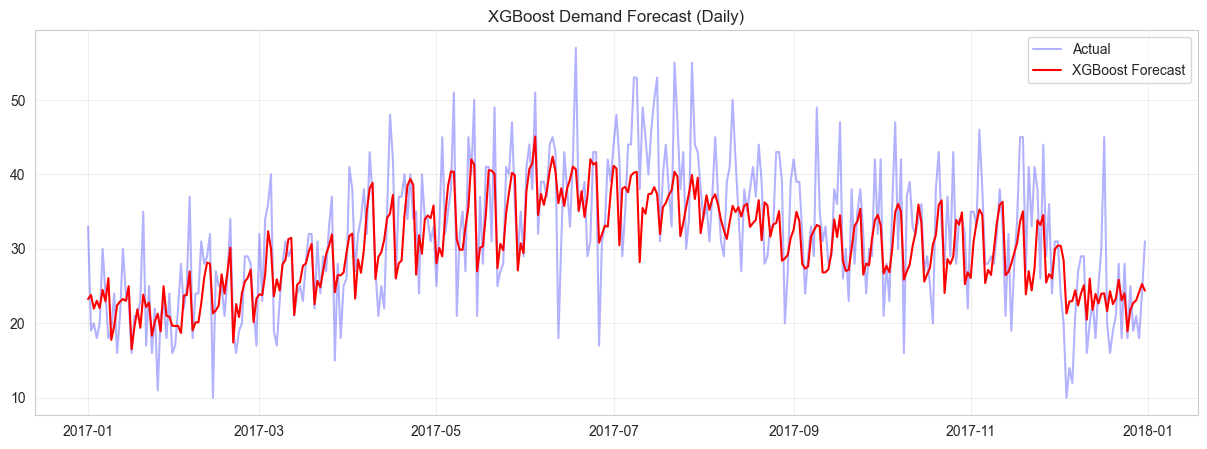

MAE: 5.21
RMSE: 6.57


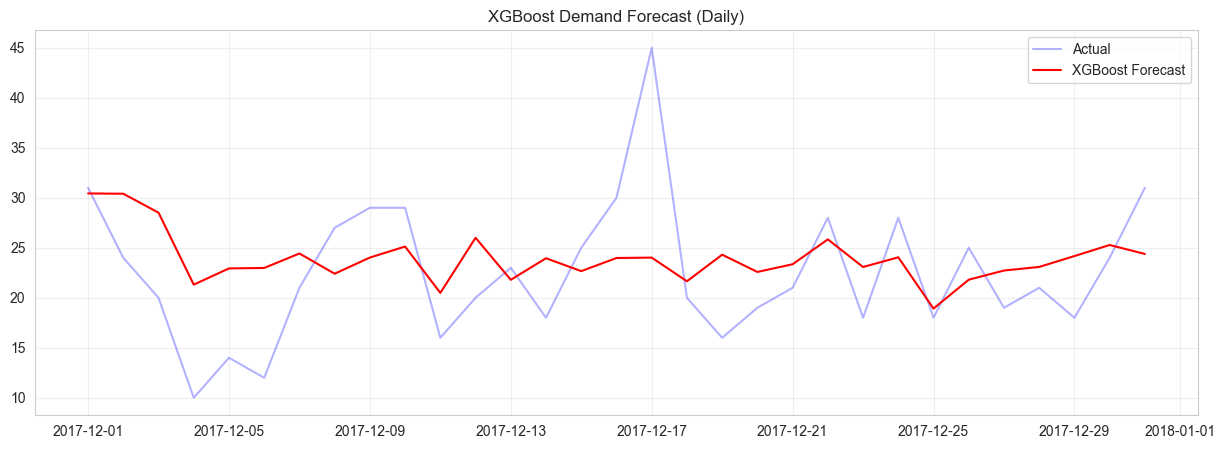

In [ ]:
def predict_xgboost(model, test): 
    FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 
                'lag7', 'lag14', 'lag30', 'rolling_mean_7']
    TARGET = 'sales'

    X_test = test[FEATURES]
    y_test = test[TARGET]
   # Predict
    test['prediction'] = model.predict(X_test)

    # Calculate Metrics
    mae = mean_absolute_error(y_test, test['prediction'])
    rmse = np.sqrt(mean_squared_error(y_test, test['prediction']))

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')


    plt.figure(figsize=(12, 4))
    plt.plot(test.index, test['sales'], label='Actual', color='blue', alpha=0.3)
    plt.plot(test.index, test['prediction'], label='XGBoost Forecast', color='red')
    plt.title('XGBoost Demand Forecast (Daily)')
    plt.legend()
    plt.show()
  
predict_xgboost(model_xgb, test)
filtered = test.loc['2017-12']
predict_xgboost(model_xgb, filtered)

#### Prophet

Prophet is a forecasting tool developed by Facebook that is designed to handle time series data with strong seasonal effects and multiple seasonality. It is particularly useful for business forecasting tasks, such as sales forecasting, where there are often complex patterns in the data. Prophet is based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It is robust to missing data and shifts in the trend, and typically requires minimal tuning to produce good forecasts. Which looks like the perfect fit for our problem. 

In [17]:

def train_prophet(data, freq='D'):
    yearly = True
    weekly = True
    if freq == 'W':
        data = data.resample('W').sum()
        weekly = False
    elif freq == 'M':
        data = data.resample('M').sum()
        weakly = False

    train_prophet = data.reset_index()
    train_prophet.columns = ['ds', 'y']
    train_prophet.head()



    model = Prophet(
        yearly_seasonality=yearly,
        weekly_seasonality=weekly,
        daily_seasonality=False,
        seasonality_mode='multiplicative',  # better for retail sales
        interval_width=0.90                 # 90% CI
    )

    model.fit(train_prophet)

    return model
model_prophet = train_prophet(train_ts, freq='D')
model_prophet_weekly = train_prophet(train_ts, freq='W')
model_prophet_monthly = train_prophet(train_ts, freq='M')

14:38:41 - cmdstanpy - INFO - Chain [1] start processing
14:38:42 - cmdstanpy - INFO - Chain [1] done processing
14:38:42 - cmdstanpy - INFO - Chain [1] start processing
14:38:42 - cmdstanpy - INFO - Chain [1] done processing
14:38:42 - cmdstanpy - INFO - Chain [1] start processing
14:38:43 - cmdstanpy - INFO - Chain [1] done processing


Generating forecast for 365 periods with frequency 'D'
            sales  predicted sales
date                              
2017-01-01     33        27.761356
2017-01-02     19        17.351322
2017-01-03     20        20.635674
2017-01-04     18        19.942277
2017-01-05     20        22.822476


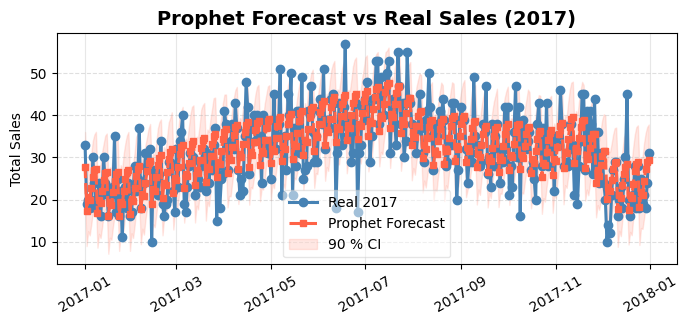

Generating forecast for 53 periods with frequency 'W'
            sales  predicted sales
date                              
2017-01-01     33       158.611351
2017-01-08    149       157.520171
2017-01-15    157       154.699165
2017-01-22    158       153.334552
2017-01-29    135       155.267611


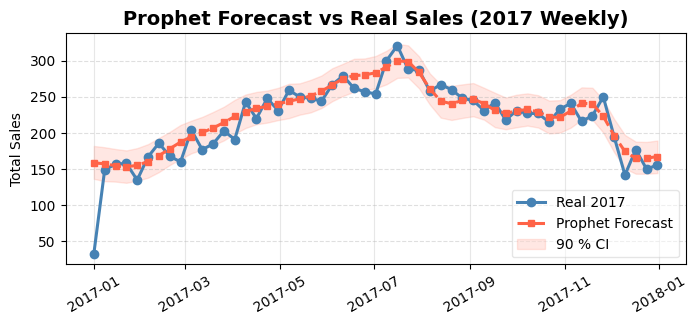

Generating forecast for 12 periods with frequency 'M'
            sales  predicted sales
date                              
2017-01-31    665       673.811909
2017-02-28    687       698.743613
2017-03-31    842       930.136406
2017-04-30   1021      1023.479040
2017-05-31   1094      1073.132001


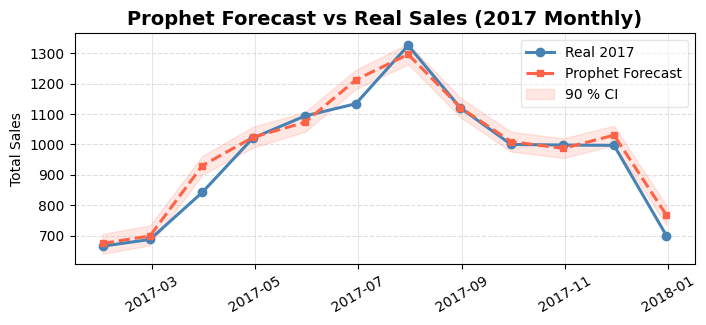

In [18]:
def evaluate_prophet(data, model, title='Prophet Forecast vs Real Sales (2017)', freq='D'):
    print(f"Generating forecast for {len(data)} periods with frequency '{freq}'")

    # Forecast 2017 (365 days) ────────────────────────────────────────
    future   = model.make_future_dataframe(periods=len(data), freq=freq)
    forecast = model.predict(future)
    
    # Keep only 2017
    
    forecast_2017 = (forecast[forecast['ds'].dt.year == 2017]
        [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        .set_index('ds')
    )

    #filtered dataset
    #forecast_2017 = forecast_2017.loc['2017-12']
    
    pred_mean     = forecast_2017['yhat']
    pred_ci_lower = forecast_2017['yhat_lower']
    pred_ci_upper = forecast_2017['yhat_upper']

    fig, ax = plt.subplots(figsize=(8, 3))

    # Real 2017 monthly
    ax.plot(data.index, data.values, color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017 ')

    # Prophet forecast
    ax.plot(pred_mean.index, pred_mean.values, color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,label='Prophet Forecast')

    # CI band
    ax.fill_between(pred_mean.index, pred_ci_lower, pred_ci_upper, color='tomato', alpha=0.15, label='90 % CI')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Total Sales')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(framealpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    data = data.to_frame(name='sales')
    data['predicted sales'] = forecast_2017['yhat']
    print(data.head())
    plt.show()

evaluate_prophet(test_ts, model_prophet)
evaluate_prophet(test_weekly, model_prophet_weekly, title='Prophet Forecast vs Real Sales (2017 Weekly)', freq='W')
evaluate_prophet(test_monthly, model_prophet_monthly, title='Prophet Forecast vs Real Sales (2017 Monthly)', freq='M')

In [19]:

def calculate_metrics(test_data, model, freq='D'):
    # Align the test data and forecast on the index (ds)
    # Ensure we only compare dates that exist in both

    forecast = model.predict(model.make_future_dataframe(periods=len(test_data), freq=freq))
    forecast_2017 = (forecast[forecast['ds'].dt.year == 2017]
        [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        .set_index('ds')
    )

    comparison = pd.concat([test_data, forecast_2017['yhat']], axis=1).dropna()
    
    y_true = comparison.iloc[:, 0] # Real sales
    y_pred = comparison['yhat']    # Predicted sales
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE %': mape}

# Execute for all three
metrics_daily = calculate_metrics(test_ts, model_prophet)
metrics_weekly = calculate_metrics(test_weekly,model_prophet_weekly , freq='W')
metrics_monthly = calculate_metrics(test_monthly, model_prophet_monthly, freq='M')


# Display results
results = pd.DataFrame([metrics_daily, metrics_weekly, metrics_monthly], 
                       index=['Daily', 'Weekly', 'Monthly'])
print(results)

               MAE       RMSE     MAPE %
Daily     4.488075   5.614902  16.076734
Weekly   14.738477  22.947790  13.170797
Monthly  30.215964  42.198369   3.329172


Based on the result of the models, we will use the Prophet model to forecast, thanks to the fact that have yearly seasonality and weekly_seasonality. 

For our needs, we will continue with the weekly dataset to measure the inventory needed, even if we know perfectly based on the MAPE of 3.3% thet the Monthly dataset is more accurate, but we need to have a more granular forecast to manage the inventory.


### Inventory

Now what it's important is to predict the inventory needed for the next week, month, or year, to avoid running out of stock, and to avoid overstocking. 

We will predict the inventory needed with the next formula: 

$$inventory\_needed = predicted\_demand + safety\_stock$$

The safety stock represent the stock I need to have to avoid running out of stock (taking in count the standard deviation), and is calculated with the next formula:

$$ SafetyStock = Z \times \sigma_{demand} \times  \sqrt{Review + LeadTime}$$

- Z = service level (e.g. 1.65 for 95%)
- σ demand = standard deviation of demand
- LeadTime = replenishment time in days (the time from hitting "order" to the boxes arriving)
- Review Period: the time until the next order.

| Service Level | Z-Value (Factor) | Risk of Stockout | Common Use Case |
| :--- | :---: | :---: | :--- |
| **80%** | 0.84 | 20% | Low turnover or low-margin products. |
| **90%** | 1.28 | 10% | Standard products. |
| **95%** | 1.65 | 5% | Most retail products. |
| **98%** | 2.05 | 2% | Star products or high priority. |
| **99%** | 2.33 | 1% | Critical items (medical, unique parts). |

In [20]:
data = test_weekly
print(f"Generating forecast for {len(data)} periods with frequency weekly")

future   = model_prophet_weekly.make_future_dataframe(periods=53, freq='W')
forecast = model_prophet_weekly.predict(future)
    
# Keep only 2017
    
forecast_2017 = (forecast[forecast['ds'].dt.year == 2017]
        [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        .set_index('ds')
    )

pred_mean     = forecast_2017['yhat']
pred_ci_lower = forecast_2017['yhat_lower']
pred_ci_upper = forecast_2017['yhat_upper']

data = data.to_frame(name='sales')
data['predicted_sales'] = round(forecast_2017['yhat'],2)
data.index = pd.to_datetime(data.index)
data.tail()


Generating forecast for 53 periods with frequency weekly


,sales,predicted_sales
date,,
2017-12-03,195,196.53
2017-12-10,142,174.51
2017-12-17,177,164.87
2017-12-24,150,165.12
2017-12-31,156,167.50


In [21]:
#In supply chain projects, something like this is often used:
lead_time = 5 # 4 weeks for the next order, and 1 week for the delivery time, so 5 weeks in total

#95% service level
Z         = 1.65

df_ss = data.copy()


df_ss['std_dev'] = df_ss['predicted_sales'].rolling(window=lead_time -1).std()

df_ss['safety_stock'] = round(Z * df_ss['std_dev'] * np.sqrt(lead_time),2)

df_ss['safety_stock'] = df_ss['safety_stock'].bfill()
df_ss.drop(columns=['std_dev'], inplace=True)

print("Safety stock per store (units):")
print(df_ss.head(10))

Safety stock per store (units):
            sales  predicted_sales  safety_stock
date                                            
2017-01-01     33           158.61          9.02
2017-01-08    149           157.52          9.02
2017-01-15    157           154.70          9.02
2017-01-22    158           153.33          9.02
2017-01-29    135           155.27          6.44
2017-02-05    167           160.60         11.77
2017-02-12    186           168.64         25.27
2017-02-19    168           178.21         36.89
2017-02-26    160           187.47         42.98
2017-03-05    204           194.91         42.02


In [22]:
#inventory needed = forecasted demand + safety stock
df_ss['inventory_needed'] = (df_ss['predicted_sales'] + df_ss['safety_stock']).round(2)
print("Inventory needed per store (units):")
print("Shape:", df_ss.shape)
df_ss.head(10)

Inventory needed per store (units):
Shape: (53, 4)


,sales,predicted_sales,safety_stock,inventory_needed
date,,,,
2017-01-01,33,158.61,9.02,167.63
2017-01-08,149,157.52,9.02,166.54
2017-01-15,157,154.70,9.02,163.72
2017-01-22,158,153.33,9.02,162.35
2017-01-29,135,155.27,6.44,161.71
2017-02-05,167,160.60,11.77,172.37
2017-02-12,186,168.64,25.27,193.91
2017-02-19,168,178.21,36.89,215.10
2017-02-26,160,187.47,42.98,230.45


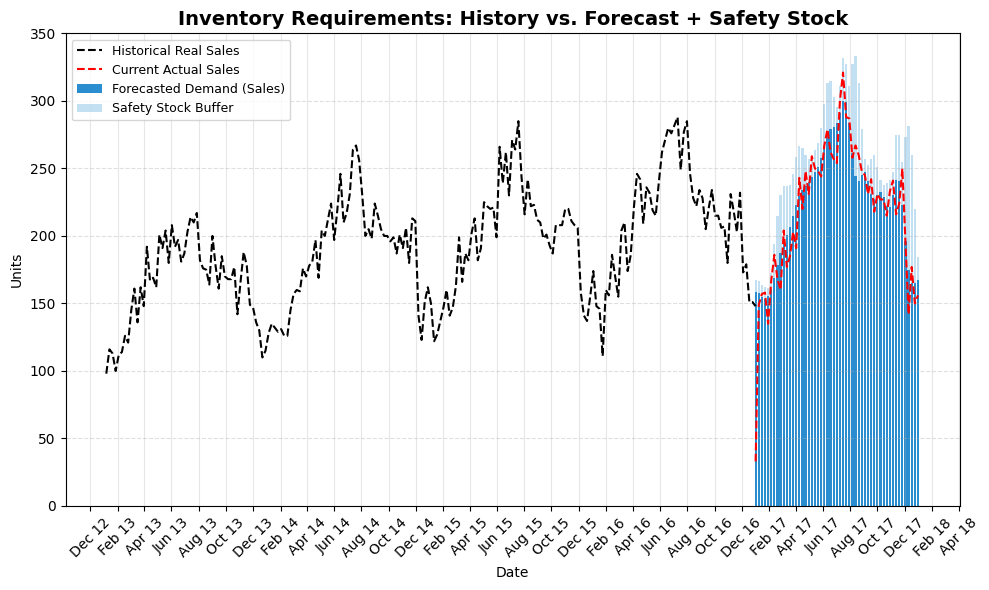

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_weekly.index, train_weekly.values, color='black', linewidth=1.5, linestyle='--', label='Historical Real Sales')

ax.bar(df_ss.index, df_ss['predicted_sales'], width=5, color="#0379c7", alpha=0.85, label='Forecasted Demand (Sales)')

ax.bar(df_ss.index, df_ss['safety_stock'], width=5, color="#55a5da", alpha=0.35, bottom=df_ss['predicted_sales'], label='Safety Stock Buffer')


ax.plot(test_weekly.index, test_weekly.values, color='red', linewidth=1.5, linestyle='--', label='Current Actual Sales')
# Formatting
ax.set_title('Inventory Requirements: History vs. Forecast + Safety Stock', fontsize=14, fontweight='bold')
ax.set_ylabel('Units')
ax.set_xlabel('Date')

# Improve Date Ticks to handle a longer timeline
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Show every 2nd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

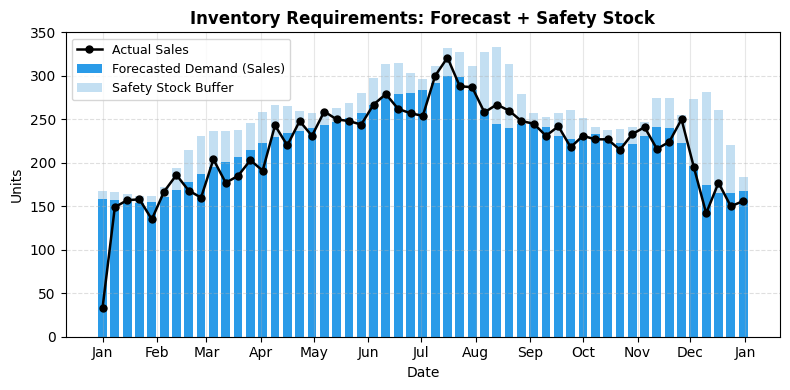

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
train_ts = item15_store_2[item15_store_2.index.year < 2017]

ax.bar(df_ss.index, df_ss['predicted_sales'], width=5, color="#048ae4", alpha=0.85, label='Forecasted Demand (Sales)')
ax.bar(df_ss.index, df_ss['safety_stock'], width=5, color="#55a5da", alpha=0.35, bottom=df_ss['predicted_sales'], label='Safety Stock Buffer')
ax.plot(df_ss.index, df_ss['sales'], color='black', linewidth=1.8, marker='o', markersize=5, zorder=5, label='Actual Sales')

# Formatting
ax.set_title('Inventory Requirements: Forecast + Safety Stock', fontsize=12, fontweight='bold')
ax.set_ylabel('Units')
ax.set_xlabel('Date')

# Date formatting for X-axis (showing months)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

#### Quantity order
Perfect, now we have the inventory needed weekly, but we need to know how much we need to order for the next month.



To determine the quantity to order ($Q$), use this logic:$$Q = \text{Target Stock Level} (S) - \text{Inventory on Hand} - \text{Inventory on Order}$$

Let's use common data for the variables: 

$inventory\_on\_hand = 50$ units

$inventory\_on\_order = 0$ units

Calculate Target Stock Level($S$)

We will cover the average demand for the next 5 weeks plus the safety buffer.

$$Target Stock Level (S) = \left( \sum_{i=1}^{R+L} \text{Forecast}_i \right) + \left( Z \times \sigma_{\text{weekly}} \times \sqrt{R+L} \right)$$
$$S = Predicted Demand + Safety Stock$$


In [25]:
inventory_on_hand = 50   # Current physical stock
inventory_on_order = 0  # Stock already shipped but not yet received

df_ss['amount_order'] = (df_ss['inventory_needed'] - inventory_on_hand - inventory_on_order).clip(lower=0)

# Display the first few rows
print(df_ss[['inventory_needed', 'amount_order']].head())

            inventory_needed  amount_order
date                                      
2017-01-01            167.63        117.63
2017-01-08            166.54        116.54
2017-01-15            163.72        113.72
2017-01-22            162.35        112.35
2017-01-29            161.71        111.71


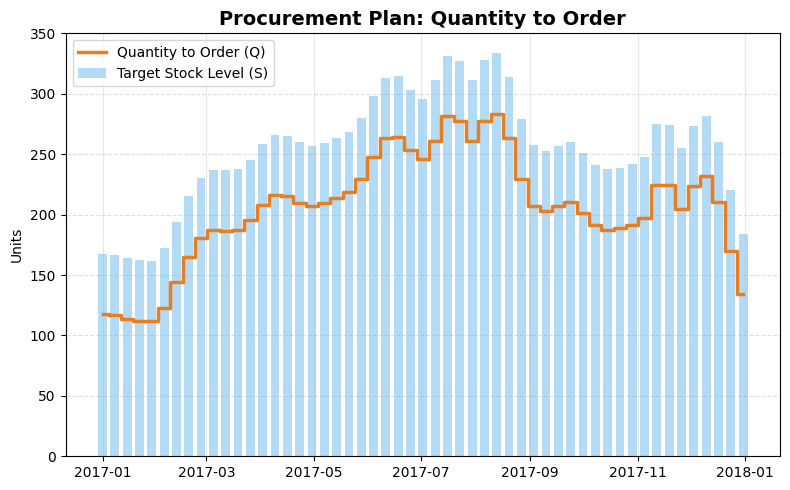

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# The Target Level (Stacked Bar)
ax.bar(df_ss.index, df_ss['inventory_needed'], width=5, color="#048ae4", 
       alpha=0.3, label='Target Stock Level (S)')

# The actual quantity you need to buy
ax.step(df_ss.index, df_ss['amount_order'], where='mid', color='#e67e22', 
        linewidth=2.5, label='Quantity to Order (Q)')

# Formatting
ax.set_title('Procurement Plan: Quantity to Order', fontsize=14, fontweight='bold')
ax.set_ylabel('Units')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [27]:
df_ss['demand_during_lead_time'] = df_ss['predicted_sales'].rolling(window=lead_time).sum()
df_ss['target_stock'] = df_ss['demand_during_lead_time'] + df_ss['safety_stock']
# Reordering columns for a clear "Procurement Dashboard" view
display(df_ss.head(8))

,sales,predicted_sales,safety_stock,inventory_needed,amount_order,demand_during_lead_time,target_stock
date,,,,,,,
2017-01-01,33,158.61,9.02,167.63,117.63,NaN,NaN
2017-01-08,149,157.52,9.02,166.54,116.54,NaN,NaN
2017-01-15,157,154.70,9.02,163.72,113.72,NaN,NaN
2017-01-22,158,153.33,9.02,162.35,112.35,NaN,NaN
2017-01-29,135,155.27,6.44,161.71,111.71,779.43,785.87
2017-02-05,167,160.60,11.77,172.37,122.37,781.42,793.19
2017-02-12,186,168.64,25.27,193.91,143.91,792.54,817.81
2017-02-19,168,178.21,36.89,215.10,165.10,816.05,852.94


In [28]:
158.61	+ 157.52 + 154.70 + 153.33 + 155.27 + 6.44 - 50

735.87

In [71]:
df_ss['is_review_day'] = [True if i % 4 == 0 else False for i in range(len(df_ss))]

def calculate_monthly_q(row):
    if row['is_review_day']:
        # Order up to the Reorder Point (which covers 5 weeks of risk)
        return max(0, row['target_stock'] - (inventory_on_hand + inventory_on_order))
    else:
        return 0

df_ss['monthly_order_amount'] = df_ss.apply(calculate_monthly_q, axis=1)
print(df_ss[['inventory_needed', 'target_stock', 'monthly_order_amount']].head(15))

            inventory_needed  target_stock  monthly_order_amount
date                                                            
2017-01-01            167.63           NaN                  0.00
2017-01-08            166.54           NaN                  0.00
2017-01-15            163.72           NaN                  0.00
2017-01-22            162.35           NaN                  0.00
2017-01-29            161.71        785.87                735.87
2017-02-05            172.37        793.19                  0.00
2017-02-12            193.91        817.81                  0.00
2017-02-19            215.10        852.94                  0.00
2017-02-26            230.45        893.17                843.17
2017-03-05            236.93        931.85                  0.00
2017-03-12            236.73        965.96                  0.00
2017-03-19            237.43        998.79                  0.00
2017-03-26            245.56       1035.58                985.58
2017-04-02            258

Let's read the table. 
- reorder_point: it represents the total inventory you must have (On Hand + On Order) to survive the next 5 weeks.
- monthly_order_amount: the gap between your target level and your current stock, the inventory needed - the_inventory_on_hand(50).
- order_now_for_future: the quantity to order now to have the inventory needed in 5 weeks, which is the gap between the reorder point and the inventory on hand.

### Can we predict more years?

Generating forecast for 12 periods with frequency 'M'
                   yhat   yhat_lower   yhat_upper
ds                                               
2024-08-31  1533.863904  1406.809623  1668.238412
2024-09-30  1412.573307  1288.954195  1539.260340
2024-10-31  1352.748255  1229.503937  1477.912998
2024-11-30  1400.301744  1271.564440  1527.021542
2024-12-31  1074.509575   974.248347  1174.219815


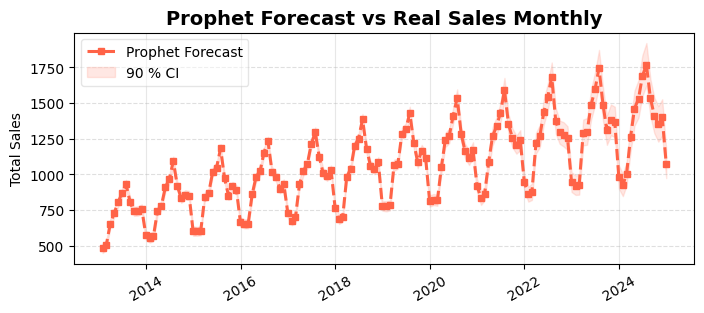

Generating forecast for 53 periods with frequency 'W'
                  yhat  yhat_lower  yhat_upper
ds                                            
2024-11-24  315.612643  280.468831  349.339776
2024-12-01  280.405816  249.541195  310.525509
2024-12-08  246.868344  218.464365  275.869325
2024-12-15  229.038432  201.673556  257.216962
2024-12-22  226.835318  198.558028  256.595711


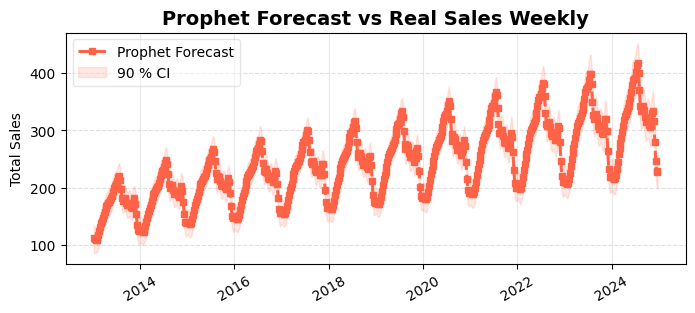

Generating forecast for 53 periods with frequency 'W'
                  yhat  yhat_lower  yhat_upper
ds                                            
2023-12-03  262.982665  235.788880  289.636549
2023-12-10  232.817872  205.431991  258.584370
2023-12-17  218.780886  191.622649  246.553268
2023-12-24  218.445231  192.995021  246.354148
2023-12-31  221.639984  195.501240  248.744153


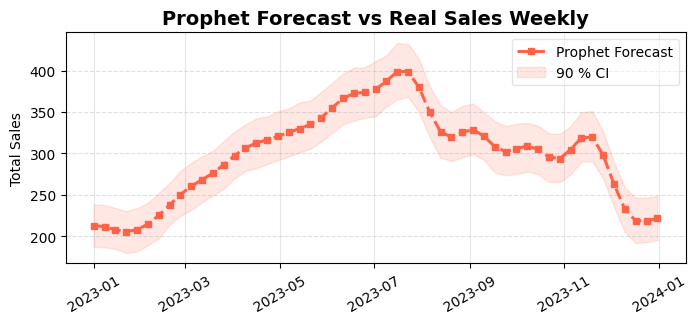

In [30]:
def evaluate_prophet_more(data, model, title='Prophet Forecast vs Real Sales (2017)', freq='D', filter=None):
    print(f"Generating forecast for {len(data)} periods with frequency '{freq}'")

    # Forecast 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024 ────────────────────────────────────────
    period = 12*8 if freq == 'M' else 365*8 if freq == 'D' else 52*8
    future   = model.make_future_dataframe(periods=period, freq=freq)
    forecast = model.predict(future)
    
    # Keep only 2017
    if filter is not None: 
    
        forecast = (forecast[forecast['ds'].dt.year == filter]
            [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
            .set_index('ds')
        )
    else: 
        forecast = (forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].set_index('ds'))

    #filtered dataset
    #forecast_2017 = forecast_2017.loc['2017-12']
    
    pred_mean     = forecast['yhat']
    pred_ci_lower = forecast['yhat_lower']
    pred_ci_upper = forecast['yhat_upper']

    fig, ax = plt.subplots(figsize=(8, 3))

    # Real 2017 monthly
    #ax.plot(data.index, data.values, color='steelblue', linewidth=2.2, marker='o', markersize=6, label='Real 2017 ')

    # Prophet forecast
    ax.plot(pred_mean.index, pred_mean.values, color='tomato', linewidth=2.2, linestyle='--', marker='s', markersize=5,label='Prophet Forecast')

    # CI band
    ax.fill_between(pred_mean.index, pred_ci_lower, pred_ci_upper, color='tomato', alpha=0.15, label='90 % CI')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Total Sales')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(framealpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    data = data.to_frame(name='sales')
    data['predicted sales'] = forecast['yhat']
    print(forecast.tail())
    plt.show()

evaluate_prophet_more(test_monthly, model_prophet_monthly, title=f'Prophet Forecast vs Real Sales Monthly', freq='M')
evaluate_prophet_more(test_weekly, model_prophet_weekly, title=f'Prophet Forecast vs Real Sales Weekly', freq='W')
evaluate_prophet_more(test_weekly, model_prophet_weekly, title=f'Prophet Forecast vs Real Sales Weekly', freq='W', filter=2023)

Yes, we can predict more years with the same model, but we need to be careful with the seasonality, because if we want to predict more years, we need to have more data to train the model, the model start to loss accuracy if the prediction is bigger than the data used to train it. But in general works well, we even can predict an specific date: 

In [31]:
target_date = pd.DataFrame({'ds': ['2023-12-31']})

# Predict only for that date
single_forecast = model_prophet_weekly.predict(target_date)

print(f"Forecast for {target_date.iloc[0,0]}: {single_forecast['yhat'].iloc[0]:.2f}")

Forecast for 2023-12-31: 221.64


### Next Steps:

We already have the predictions of the monthly orders, with safety stocks, with a safe lead time of 1 week to receive the order from when the order was placed. Now, we will do it for all the products, and finally with all the products for all the stores, to have a complete procurement dashboard.

In [34]:
df_train.head()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [35]:
def train_prophet_model(resampled_data):
    """
    Trains a Prophet model on a pre-resampled weekly or monthly dataframe.
    """
    # Prepare Prophet format
    df_p = resampled_data.reset_index()
    df_p.columns = ['ds', 'y']

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False, # False because we are at Weekly frequency
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.90
    )
    
    model.fit(df_p)
    return model

In [87]:
all_forecasts = {} # To store the final results
stores = df_train['store'].unique()
items = df_train['item'].unique()

print(f"Starting Production Training for {len(stores)*len(items)} combinations...")

for s_id in stores:
    for i_id in items:

        ts = df_train[(df_train['store'] == s_id) & (df_train['item'] == i_id)]['sales'].resample('W').sum()
        train_data = ts[ts.index.year < 2017]
        model = train_prophet_model(train_data)
        future = model.make_future_dataframe(periods=52, freq='W')
        forecast = model.predict(future)
        
        forecast_2017 = forecast[forecast['ds'].dt.year == 2017][['ds', 'yhat']].set_index('ds')
        all_forecasts[f"store_{s_id}_item_{i_id}"] = forecast_2017

print("Training Complete!")

16:19:39 - cmdstanpy - INFO - Chain [1] start processing


Starting Production Training for 500 combinations...


16:19:39 - cmdstanpy - INFO - Chain [1] done processing
16:19:39 - cmdstanpy - INFO - Chain [1] start processing
16:19:39 - cmdstanpy - INFO - Chain [1] done processing
16:19:40 - cmdstanpy - INFO - Chain [1] start processing
16:19:40 - cmdstanpy - INFO - Chain [1] done processing
16:19:40 - cmdstanpy - INFO - Chain [1] start processing
16:19:40 - cmdstanpy - INFO - Chain [1] done processing
16:19:40 - cmdstanpy - INFO - Chain [1] start processing
16:19:40 - cmdstanpy - INFO - Chain [1] done processing
16:19:40 - cmdstanpy - INFO - Chain [1] start processing
16:19:40 - cmdstanpy - INFO - Chain [1] done processing
16:19:41 - cmdstanpy - INFO - Chain [1] start processing
16:19:41 - cmdstanpy - INFO - Chain [1] done processing
16:19:41 - cmdstanpy - INFO - Chain [1] start processing
16:19:41 - cmdstanpy - INFO - Chain [1] done processing
16:19:41 - cmdstanpy - INFO - Chain [1] start processing
16:19:41 - cmdstanpy - INFO - Chain [1] done processing
16:19:41 - cmdstanpy - INFO - Chain [1] 

Training Complete!


In [89]:
# Get specific replenishment plan
plan = all_forecasts['store_10_item_50']
print(plan.head())

                  yhat
ds                    
2017-01-01  407.472538
2017-01-08  399.738771
2017-01-15  397.061171
2017-01-22  404.849020
2017-01-29  418.997853


In [82]:
# Dictionaries to store our 'Production Assets'
models_dict = {}
test_data_dict = {}

# Example loop for a few items (expand to all 50 later)
stores = df_train['store'].unique()
best_sellers = df_train.groupby('item')['sales'].sum().sort_values(ascending=False).index 
items = best_sellers# Testing with 5 items first

for s_id in stores:
    for i_id in items:
        # Filter and Resample
        ts = df_train[(df_train['store'] == s_id) & (df_train['item'] == i_id)]['sales']
        ts_weekly = ts.resample('W').sum()
        
        # Split
        train_data = ts_weekly[ts_weekly.index.year < 2017]
        test_data = ts_weekly[ts_weekly.index.year == 2017]
        
        # Train and Store
        model = train_prophet(train_data, freq='W') # Using your function
        
        # Save to dictionaries
        models_dict[(s_id, i_id)] = model
        test_data_dict[(s_id, i_id)] = test_data

15:42:11 - cmdstanpy - INFO - Chain [1] start processing
15:42:11 - cmdstanpy - INFO - Chain [1] done processing
15:42:11 - cmdstanpy - INFO - Chain [1] start processing
15:42:11 - cmdstanpy - INFO - Chain [1] done processing
15:42:11 - cmdstanpy - INFO - Chain [1] start processing
15:42:11 - cmdstanpy - INFO - Chain [1] done processing
15:42:11 - cmdstanpy - INFO - Chain [1] start processing
15:42:11 - cmdstanpy - INFO - Chain [1] done processing
15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:12 - cmdstanpy - INFO - Chain [1] done processing
15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:12 - cmdstanpy - INFO - Chain [1] done processing
15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:12 - cmdstanpy - INFO - Chain [1] done processing
15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:12 - cmdstanpy - INFO - Chain [1] done processing
15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:12 - cmdstanpy - INFO - Chain [1]

In [90]:
def get_store_item_report(store_id, item_id, year=2017):
    """
    Interface to query a specific store-item replenishment plan.
    """
    key = (store_id, item_id)
    
    if key not in models_dict:
        print(f"Error: Model for Store {store_id}, Item {item_id} not found.")
        return

    model = models_dict[key]
    data = test_data_dict[key]
    
    # Filter data for the specific year requested
    data_year = data[data.index.year == year]
    
    # 1. Generate Forecast
    future = model.make_future_dataframe(periods=len(data_year), freq='W')
    forecast = model.predict(future)
    forecast_year = forecast[forecast['ds'].dt.year == year].set_index('ds')
    
    # 2. Safety Stock Logic (Calculated from residuals of this specific model)
    # We use RMSE as the sigma for this specific item
    train_forecast = model.predict(model.make_future_dataframe(periods=0))
    # Note: Ensure alignment for residual calculation
    sigma = np.std(data.values - train_forecast['yhat'].values[:len(data)]) 
    ss = 1.65 * sigma * np.sqrt(1) # Z=1.65 for 95% safety
    
    # 3. Visualization
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Real Data
    ax.plot(data_year.index, data_year.values, color='steelblue', 
            marker='o', label=f'Real Sales {year}')
    
    # Forecast & Safety Stock Layer
    ax.plot(forecast_year.index, forecast_year['yhat'], color='tomato', 
            linestyle='--', label='Prophet Prediction')
    
    # Order-Up-To Level (Prediction + Safety Stock)
    order_level = forecast_year['yhat'] + ss
    ax.step(forecast_year.index, order_level, where='mid', color='green', 
            alpha=0.6, label='Inventory Target (Incl. Safety Stock)')
    
    ax.fill_between(forecast_year.index, forecast_year['yhat_lower'], 
                    forecast_year['yhat_upper'], color='tomato', alpha=0.1)

    ax.set_title(f"Inventory Plan: Store {store_id} | Item {item_id}", fontweight='bold')
    ax.set_ylabel("Units")
    ax.legend(loc='upper left', framealpha=0.6)
    plt.tight_layout()
    plt.show()

    # 4. Data Summary
    report_df = data_year.to_frame(name='Real Sales')
    report_df['Forecast'] = forecast_year['yhat']
    report_df['Safety Stock'] = ss
    report_df['Order-Up-To'] = np.ceil(order_level)
    
    print(f"--- Replenishment Report: Store {store_id}, Item {item_id} ---")
    print(report_df.head())

In [84]:
unique_stores = set(int(key[0]) for key in models_dict.keys())
unique_items = set(int(key[1]) for key in models_dict.keys())
print("Posible combinations of store and item IDs to test:")
print(f"Available Stores: {sorted(unique_stores)}")
print(f"Available Items: {sorted(unique_items)}")

Posible combinations of store and item IDs to test:
Available Stores: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Available Items: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


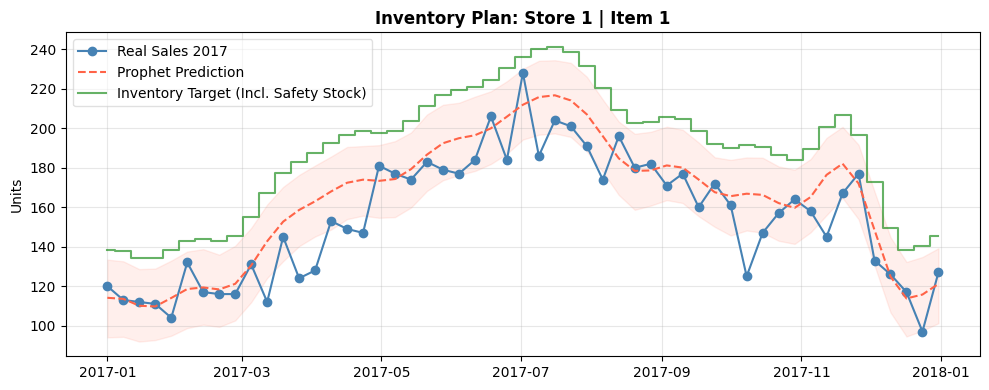

--- Replenishment Report: Store 1, Item 1 ---
            Real Sales    Forecast  Safety Stock  Order-Up-To
date                                                         
2017-01-01         120  114.114103     24.440197        139.0
2017-01-08         113  113.564777     24.440197        139.0
2017-01-15         112  110.090203     24.440197        135.0
2017-01-22         111  109.730682     24.440197        135.0
2017-01-29         104  114.021638     24.440197        139.0


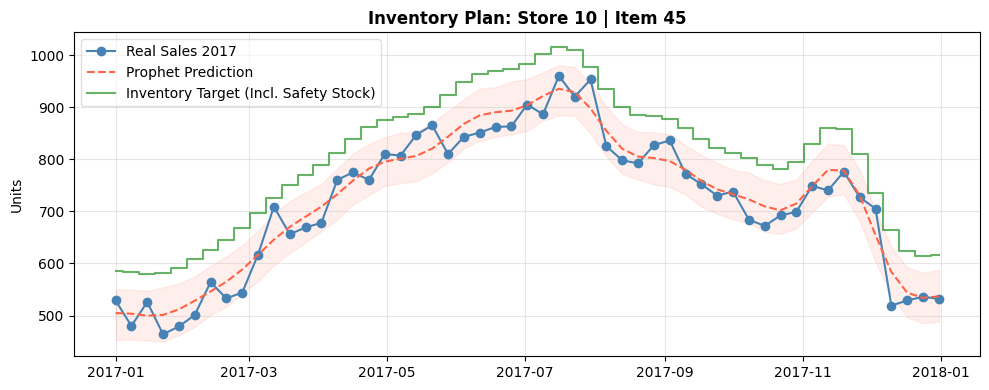

--- Replenishment Report: Store 10, Item 45 ---
            Real Sales    Forecast  Safety Stock  Order-Up-To
date                                                         
2017-01-01         529  504.720648     80.063071        585.0
2017-01-08         480  503.561971     80.063071        584.0
2017-01-15         526  499.693082     80.063071        580.0
2017-01-22         464  501.194056     80.063071        582.0
2017-01-29         479  511.891244     80.063071        592.0


In [ ]:
#  Check Item 1 in Store 2
get_store_item_report(store_id=1, item_id=1, year=2017)

get_store_item_report(store_id=10, item_id=45, year=2017)

In [103]:
def get_replenishment_report(store_id, item_id, inventory_on_hand=50, inventory_on_order=0, lead_time=5):
    """
    Generates a detailed replenishment report for a specific store and item.
    """
    key = (store_id, item_id)
    if key not in models_dict:
        print(f"Error: Model for Store {store_id}, Item {item_id} not found.")
        return None

    # 1. Retrieve Assets
    model = models_dict[key]
    actual_sales = test_data_dict[key] # This is the 2017 'Real Sales'

    # 2. Generate Forecast for 2017
    future = model.make_future_dataframe(periods=len(actual_sales), freq='W')
    forecast = model.predict(future)
    forecast_2017 = forecast[forecast['ds'].dt.year == 2017].set_index('ds')

    # 3. Calculate Volatility (Sigma) from training residuals
    # We use this to get a custom Safety Stock for this specific item/store
    train_forecast = model.predict(model.make_future_dataframe(periods=0))
    # Standard deviation of errors during training
    sigma = np.std(actual_sales.values - forecast_2017['yhat'].values) 
    Z = 1.65 # 95% Service Level
    
    # 4. Build the Replenishment Table
    df_ss = actual_sales.to_frame(name='sales')
    df_ss['predicted_sales'] = round(forecast_2017['yhat'],2)
    
    # Safety Stock Logic
    df_ss['safety_stock'] = (Z * sigma * np.sqrt(lead_time)).round(2)
    df_ss['inventory_needed'] = (df_ss['predicted_sales'] + df_ss['safety_stock']).round(2)
    
    # Simple Weekly Order Logic
    df_ss['amount_order'] = (df_ss['inventory_needed'] - inventory_on_hand - inventory_on_order).clip(lower=0)
    
    # 5. Production/Monthly Review Logic
    # If ordering for a month, we look at demand over the lead time window
    df_ss['demand_lead_time'] = df_ss['predicted_sales'].rolling(window=lead_time).sum().bfill()
    df_ss['target_stock'] = (df_ss['demand_lead_time'] + df_ss['safety_stock']).round(2)
    
    # Review Day Logic (Every 4 weeks)
    df_ss['is_review_day'] = [True if i % 4 == 0 else False for i in range(len(df_ss))]

    def calculate_monthly_q(row):
        if row['is_review_day']:
            # Order up to the Target Stock
            return max(0, row['target_stock'] - (inventory_on_hand + inventory_on_order))
        else:
            return 0

    df_ss['monthly_order_amount'] = df_ss.apply(calculate_monthly_q, axis=1).round(2)
    
    return df_ss

"""Posible combinations of store and item IDs to test:
Available Stores: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Available Items: [8, 13, 15, 18, 22, 25, 28, 36, 38, 45]"""
item = 18
report = get_replenishment_report(store_id=2, item_id=item)

print(f"Replenishment Table for Store 2, Item {item}:")
display(report[['sales', 'predicted_sales', 'inventory_needed','demand_lead_time','target_stock','monthly_order_amount']].tail())

Replenishment Table for Store 2, Item 18:


,sales,predicted_sales,inventory_needed,demand_lead_time,target_stock,monthly_order_amount
date,,,,,,
2017-12-03,774,781.27,932.49,4508.83,4660.05,4610.05
2017-12-10,634,698.90,850.12,4283.79,4435.01,0.00
2017-12-17,621,660.62,811.84,3979.40,4130.62,0.00
2017-12-24,680,653.90,805.12,3677.85,3829.07,0.00
2017-12-31,618,652.05,803.27,3446.74,3597.96,3547.96


### Can we generate a purchase order report for the next month?

In [108]:
def generate_purchase_order(store_id, target_date, inventory_on_hand=50):
    """
    Simulates a purchase order for all 50 items in a specific store 
    for a specific date in the future.
    """
    po_list = []
    
    # We will assume items 1-50 are in your models_dict
    items = range(1, 51) 
    target_dt = pd.to_datetime(target_date)
    
    # We define the exposure period (4 weeks of review + 1 week lead time = 5 weeks)
    exposure_weeks = 5
    Z = 1.65 # 95% Service Level
    
    print(f"--- Simulating Purchase Order for Store {store_id} | Date: {target_date} ---")

    for i_id in items:
        key = (store_id, i_id)
        if key not in models_dict:
            continue
            
        model = models_dict[key]
        
        # 1. Forecast the demand starting from the target date
        # We predict a bit further into 2018 to ensure we cover the 5-week window
        future = model.make_future_dataframe(periods=70, freq='W') # Extending from 2017 into 2018
        forecast = model.predict(future)
        
        # 2. Extract the 5 weeks starting from our target date
        # This covers the demand we need to order for today
        forecast_window = forecast[forecast['ds'] >= target_dt].head(exposure_weeks)
        total_forecasted_demand = forecast_window['yhat'].sum()
        
        # 3. Calculate the Item-Specific Safety Stock
        # We retrieve the RMSE/Sigma calculated during the training phase
        # For simulation, we'll re-calculate from training residuals if not stored
        train_forecast = model.predict(model.make_future_dataframe(periods=0))
        # (Assuming you have access to the train/test data in your environment)
        # We'll use a standard sigma based on the item's historical volatility
        sigma = np.std(forecast_window['yhat']) # Approximation for simulation
        ss = Z * sigma * np.sqrt(exposure_weeks)
        
        # 4. Final Calculation: Target Stock - Inventory On Hand
        target_stock = total_forecasted_demand + ss
        amount_to_purchase = max(0, target_stock - inventory_on_hand)
        
        po_list.append({
            "item": i_id,
            "amount_to_purchase": round(amount_to_purchase)
        })

    # Create the final Purchase Order Dataset
    purchase_order = pd.DataFrame(po_list)
    return purchase_order

# --- RUN THE SIMULATION ---
# We simulate Store 10 for the date you requested
simulation_po = generate_purchase_order(store_id=1, target_date='2018-02-26')

# Display the final Purchase Order for 50 items
print(simulation_po)

--- Simulating Purchase Order for Store 1 | Date: 2018-02-26 ---
    item  amount_to_purchase
0      1                 787
1      2                2183
2      3                1280
3      4                 757
4      5                 651
5      6                2247
6      7                2084
7      8                2809
8      9                1829
9     10                2548
10    11                2503
11    12                2524
12    13                3030
13    14                2110
14    15                3159
15    16                 897
16    17                1134
17    18                3015
18    19                1460
19    20                1687
20    21                1390
21    22                2945
22    23                1043
23    24                2355
24    25                2963
25    26                1821
26    27                 738
27    28                3259
28    29                2437
29    30                1510
30    31                2077
31    3

In [109]:
# To highlight the top 5 largest investments for Store 10
top_orders = simulation_po.sort_values(by='amount_to_purchase', ascending=False).head(5)
print("Top 5 Items to Restock (Highest Investment):")
print(top_orders)

Top 5 Items to Restock (Highest Investment):
    item  amount_to_purchase
27    28                3259
14    15                3159
12    13                3030
17    18                3015
24    25                2963


In [110]:
# 1. Define the parameters for the full report
target_date = '2018-02-26'
file_name = f"Purchase_Order_{target_date}.xlsx"
all_stores = range(1, 11) # Stores 1 to 10

print(f"Generating Master Purchase Order for {target_date}...")

# 2. Use ExcelWriter to handle multiple sheets
with pd.ExcelWriter(file_name, engine='xlsxwriter') as writer:
    for s_id in all_stores:
        # Generate the PO for the current store using your function
        # (Using your generate_purchase_order function logic)
        df_store_po = generate_purchase_order(store_id=s_id, target_date=target_date)
        
        # 3. Save to Excel on a specific sheet
        sheet_label = f"Store {s_id}"
        df_store_po.to_excel(writer, sheet_name=sheet_label, index=False)
        
        # Optional: Add some basic formatting to the Excel sheet
        worksheet = writer.sheets[sheet_label]
        worksheet.set_column('A:A', 10) # Set 'item' column width
        worksheet.set_column('B:B', 25) # Set 'amount_to_purchase' column width

print(f"Report saved as: {file_name}")

Generating Master Purchase Order for 2018-02-26...
--- Simulating Purchase Order for Store 1 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 2 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 3 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 4 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 5 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 6 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 7 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 8 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 9 | Date: 2018-02-26 ---
--- Simulating Purchase Order for Store 10 | Date: 2018-02-26 ---
Report saved as: Purchase_Order_2018-02-26.xlsx
